# Ablation Study: Single Shared Head vs. Separate Heads for Rare Lesions
### MMRDR dataset — UWF modality — publication-quality reviewer-facing ablation (Kaggle-ready)

**One-line question.** Does giving the rare, sight-threatening PDR lesions (**NV, VH, RD**) their *own*
classifier head — instead of predicting all 7 lesions from one shared head — improve rare-lesion recall
and overall multi-label performance, **once head capacity is held constant**?

This notebook runs top-to-bottom with no manual steps. Every code cell is embedded from the experiment's
Python package (`models/`, `training/`, `evaluation/`) so the notebook and the importable modules never
diverge. Heavy training is gated behind `CFG['run_training']` (default **False**); a CPU-only unit-test
suite always runs and verifies the architecture, loss, gradient routing, and threshold logic without a GPU.

**Notebook map:** 1 Introduction · 2 Literature motivation · 3 Experiment design & hypotheses ·
4 Environment · 5 Configuration · 6 Architecture (config-selectable heads) · 7 Losses · 8 Data ·
9 Metrics & thresholds · 10 Statistics · 11 Plots · 12 Checkpointing · 13 Training loop ·
14 Unit tests · 15 Data loading & EDA · 16 Training (gated) · 17 Evaluation & plots · 18 Results ·
19 Discussion · 20 Conclusion · 21 References.

## 1. Introduction & clinical motivation

The MMRDR benchmark poses a **multi-task** problem on each retinal image: a 5-level DR severity **grade**
(0–4) and a **7-way multi-label lesion** vector in the fixed order `[MA, HE, IH, VB/IRMA, NV, VH, RD]`.
The last three — **NV** (neovascularization), **VH** (vitreous hemorrhage), **RD** (retinal detachment) —
define **proliferative DR (PDR)**, the sight-threatening stage. They are also the *rarest*: on UWF, RD has
only **238 positives out of 10,404 images (2.3%)**, versus MA at 6,938 (67%).

Under this extreme imbalance, a **single shared lesion head** must fit one linear boundary that is pulled
by gradients dominated by the abundant common lesions. A recurring reviewer question is therefore: *would a
**dedicated head** for the rare PDR lesions recover the recall the shared head loses — or is any apparent
gain just extra parameters?* This ablation answers that question rigorously, with a capacity-matched control.

**Headline metric:** mean recall of {NV, VH, RD} at per-lesion optimized thresholds (missing PDR is
clinically the worst error), guarded by macro-F1 and a negative-transfer check on the common lesions.

## 2. Literature motivation

The design is grounded in three literatures (full citations in §21):

- **Decoupling representation from classifier for long-tailed recognition.** Kang *et al.* (ICLR 2020) and
  Zhou *et al.* (BBN, CVPR 2020) show the **classifier/head**, not the shared encoder, is the lever for
  rare-class performance — directly motivating a rare-lesion-specific head. BBN's bilateral (conventional +
  re-balancing) branch is an architectural precedent for our separate head.
- **Multi-task sharing vs. separation / negative transfer.** Cross-stitch networks (Misra *et al.*, CVPR
  2016) learn how much to share and find separation helps low-data categories; task-grouping work
  (Standley *et al.* ICML 2020; Fifty *et al.* NeurIPS 2021) shows naive full sharing can hurt via negative
  transfer. Houlsby *et al.* (ICML 2019) adapters give the shared-encoder + task-specific-adapter middle
  ground (our Model C). Foo *et al.* (AAAI 2020) and Zhou *et al.* (CVPR 2019) establish shared-trunk
  multi-task DR grading + lesion learning as the baseline paradigm.
- **Imbalance-aware losses.** Focal loss (Lin *et al.*, ICCV 2017), Asymmetric Loss (Ben-Baruch *et al.*,
  ICCV 2021 — the basis of our per-class-β `AsymmetricFocalLoss`), Class-Balanced loss (Cui *et al.*, CVPR
  2019), and LDAM (Cao *et al.*, NeurIPS 2019) all target rare positives. The CXR-LT challenge (Holste
  *et al.*, MedIA 2024) is the closest long-tailed *multi-label medical* methodology template.

**Gap this fills:** these works compare *losses/sampling*; few isolate the **head topology** with a
capacity-matched control on a multi-label medical task. That is precisely this ablation.

## 3. Experiment design & hypotheses

**Hypotheses.**
- **H1 (separation helps):** vs. a **capacity-matched shared MLP head (Model A′)**, a dedicated rare head
  (**Model B**) significantly increases mean recall of {NV,VH,RD} at optimized thresholds, without a
  significant drop in common-lesion macro-F1.
- **H0 (null):** no significant B−A′ difference; any B−A gain is merely added capacity (captured by A′−A).

**Variants** — same ResNet-50+FPN trunk and 512-d pooled feature; only the lesion head differs:

| Variant | `head_mode` | Lesion head | Head params | Role |
|---|---|---|---|---|
| **A** | `shared` | `Linear(512,7)` | 3,591 | current-pipeline baseline (minimal capacity) |
| **A′** | `shared_mlp` | `Linear(512,128)→ReLU→Drop→Linear(128,7)` | 66,567 | **capacity-matched control for B** |
| **B** | `separate` | common `Linear(512,4)` + rare `MLP(512→128→3)` | 68,103 | **the hypothesis** |
| **C** | `adapter` | shared body + per-group adapters | 74,631 | soft-split middle ground |

The crux: **A′ (66,567) ≈ B (68,103)** in head budget, so **B − A′ isolates *separation*** while **A′ − A**
measures *capacity*. The pre-registered test is paired **Wilcoxon (B vs A′)** on per-seed mean rare-recall
over seeds {42, 1, 2023}, α=0.05, one-sided.

**Fairness controls.** One frozen rare-stratified train/val/test split reused by every run; identical
augmentation, optimizer (AdamW 1e-4/wd 1e-4), `ReduceLROnPlateau`, AMP, grad-clip 2.0, 60 epochs, patience
10; identical `AsymmetricFocalLoss` (β `[.7,.7,.7,.8,.95,.95,.95]`) applied to the reassembled canonical
7-vector (reduction-consistent); identical per-lesion threshold sweep fit on validation only; grade and
SupCon heads frozen. **Uncertainty task-weighting is deliberately out of scope** (it would add a confound;
a prior experiment saw its log-var hit the clamp ceiling) — task weights are fixed and equal across variants.

## 0. Kaggle environment check
Detects the runtime (Kaggle vs local), GPU count, and whether the MMRDR dataset + Kaggle API credentials
are present. Everything used here (PyTorch, torchvision, scikit-learn, OpenCV, SciPy, Kaggle CLI) is
pre-installed on Kaggle — no `pip install` needed. On 2×T4 the model auto-wraps in `DataParallel`.

In [13]:
import os, sys, platform, subprocess
import torch

ON_KAGGLE = os.path.isdir('/kaggle/input')
n_gpu = torch.cuda.device_count()
print(f"Python     : {sys.version.split()[0]} on {platform.system()}")
print(f"PyTorch    : {torch.__version__}")
print(f"On Kaggle  : {ON_KAGGLE}")
print(f"GPU count  : {n_gpu}" + (f"  -> DataParallel will be used" if n_gpu > 1 else ""))
for i in range(n_gpu):
    print(f"   [{i}] {torch.cuda.get_device_name(i)}")
if ON_KAGGLE:
    import glob as _g
    ds = _g.glob('/kaggle/input/**/UWF.csv', recursive=True)
    print("MMRDR UWF  :", ds[0] if ds else "NOT ATTACHED (add the MMRDR dataset in the sidebar)")
    has_secret = bool(os.environ.get('KAGGLE_KEY'))
    try:
        from kaggle_secrets import UserSecretsClient  # noqa: F401
        has_secret = has_secret or True
    except Exception:
        pass
    print("Kaggle API :", "add KAGGLE_USERNAME + KAGGLE_KEY as Secrets (Add-ons > Secrets) to auto-back-up checkpoints")

Python     : 3.12.13 on Linux
PyTorch    : 2.10.0+cu128
On Kaggle  : True
GPU count  : 2  -> DataParallel will be used
   [0] Tesla T4
   [1] Tesla T4
MMRDR UWF  : /kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF/UWF.csv
Kaggle API : add KAGGLE_USERNAME + KAGGLE_KEY as Secrets (Add-ons > Secrets) to auto-back-up checkpoints


## 4. Environment setup
Device + reproducibility seeding + the fixed lesion vocabulary. Embedded from `training/env.py`.

In [14]:
# ==============================================================================
# training/env.py — device, seeding, RNG snapshot, lesion vocab
# ==============================================================================
"""Runtime environment: device selection and full reproducibility seeding.

Embedded as the notebook's setup cell so `device`, `seed_everything`, and the lesion vocabulary are
available to every later cell in one flat namespace.
"""
import random

import numpy as np
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def seed_everything(seed):
    """Fix every RNG for deterministic, reproducible runs (cudnn deterministic, benchmark off)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_rng_state():
    """Snapshot RNG states so a resumed run continues the exact same stochastic stream."""
    return {
        'python': random.getstate(),
        'numpy': np.random.get_state(),
        'torch': torch.get_rng_state(),
        'cuda': torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
    }


def set_rng_state(state):
    if not state:
        return
    random.setstate(state['python'])
    np.random.set_state(state['numpy'])
    torch.set_rng_state(state['torch'])
    if state.get('cuda') is not None and torch.cuda.is_available():
        torch.cuda.set_rng_state_all(state['cuda'])


# Fixed lesion vocabulary (repo-wide constant).
LESION_NAMES = ['MA', 'HE', 'IH', 'VB/IRMA', 'NV', 'VH', 'RD']
RARE_LESION_IDX = [4, 5, 6]
COMMON_LESION_IDX = [0, 1, 2, 3]
GRADE_NAMES = [f'Grade{g}' for g in range(5)]


## 5. Configuration
Generated from `configs/*.yaml` (the single source of truth). Override `head_mode` / `seed` here to pick a
variant; `run_training=False` keeps the notebook fast. On Kaggle add **Secrets** `KAGGLE_USERNAME` and
`KAGGLE_KEY` so checkpoints auto-back-up to the dataset `krrishbaghla/checkpoint-heads-ablation`.

In [15]:
import os
import torch

CFG = {'modality': 'UWF',
 'img_size': 512,
 'test_size': 0.15,
 'val_size': 0.15,
 'stratify': True,
 'split_seed': 42,
 'head_mode': 'separate',
 'hidden_dim': 128,
 'adapter_dim': 64,
 'dropout': 0.3,
 'pretrained': True,
 'afl_gamma': 2.0,
 'afl_beta': [0.7, 0.7, 0.7, 0.8, 0.95, 0.95, 0.95],
 'grade_label_smoothing': 0.05,
 'supcon_temperature': 0.1,
 'lambda_grade': 1.0,
 'lambda_supcon': 0.5,
 'lr': 0.0001,
 'weight_decay': 0.0001,
 'epochs': 60,
 'patience': 10,
 'grad_clip': 2.0,
 'batch_size': 8,
 'num_workers': 2,
 'use_amp': True,
 'seed': 42,
 'seeds': [42, 1, 2023],
 'selection_metric': 'composite',
 'sel_rare_weight': 0.5,
 'sel_f1_weight': 0.5,
 'run_training': False,
 'thr_min': 0.05,
 'thr_max': 0.95,
 'thr_step': 0.01,
 'thr_objective': 'f1',
 'backup_to_dataset': True,
 'backup_dataset_slug': 'krrishbaghla/checkpoint-heads-ablation',
 'backup_every': 2,
 'resume': True}

EXPECTED_HEAD_PARAMS = {'shared': 3591, 'shared_mlp': 66567, 'separate': 68103, 'adapter': 74631}

# ---- run-all trains by default (flip to False to run ONLY the unit tests / no GPU work) ----
CFG['run_training'] = True
# dual-T4: bigger effective batch via DataParallel; single GPU / CPU falls back to the config value
if torch.cuda.device_count() > 1:
    CFG['batch_size'] = 16
    print(f"[hardware] {torch.cuda.device_count()} GPUs -> DataParallel, batch_size {CFG['batch_size']}")
# on any Kaggle GPU kernel use all CPU cores so the expensive UWF masking never starves the GPU(s)
if torch.cuda.is_available():
    CFG['num_workers'] = min(4, os.cpu_count() or 2)
    print(f"[hardware] num_workers -> {CFG['num_workers']} (persistent + prefetch)")

# runtime output dirs: /kaggle/working on Kaggle (backed up to a Dataset), else local package folders
_BASE = '/kaggle/working' if os.path.isdir('/kaggle/working') else os.getcwd()
DIRS = {'ckpt': os.path.join(_BASE, 'checkpoints'), 'logs': os.path.join(_BASE, 'logs'),
        'results': os.path.join(_BASE, 'results'), 'plots': os.path.join(_BASE, 'plots')}
for _d in DIRS.values():
    os.makedirs(_d, exist_ok=True)
CFG['ckpt_dir'] = DIRS['ckpt']
seed_everything(CFG['seed'])
print('run_training:', CFG['run_training'], '| batch_size', CFG['batch_size'], '| output ->', _BASE)

[hardware] 2 GPUs -> DataParallel, batch_size 16
[hardware] num_workers -> 4 (persistent + prefetch)
run_training: True | batch_size 16 | output -> /kaggle/working


## 6. Model architecture — config-selectable heads (`models/heads.py`, `models/multihead_drnet.py`)
`MultiHeadDRNet(head_mode=...)` shares the entire ResNet-50 + FPN trunk, the 512-d pooled feature, the grade
head, and the two SupCon projection heads across variants; only `classifier_lesions` changes. The split
heads (`separate`/`adapter`) concatenate `[common | rare]` logits, which is exactly canonical lesion order,
so all downstream loss/metric code is variant-agnostic.

In [16]:
# ==============================================================================
# models/heads.py — the four lesion-head variants
# ==============================================================================
"""Lesion-head variants for the shared-vs-separate ablation.

Every head consumes the SAME 512-d pooled FPN feature and emits logits for the 7 lesions in the
canonical order [MA, HE, IH, VB/IRMA, NV, VH, RD]. Because the common indices (0-3) precede the rare
indices (4-6), the split heads assemble their output by a plain concatenation [common | rare], which
is exactly canonical order and is fully differentiable (no in-place scatter needed).

Only this module changes between ablation variants; the trunk/grade-head/SupCon heads are frozen.
"""
import torch
import torch.nn as nn

COMMON_IDX = (0, 1, 2, 3)     # MA, HE, IH, VB/IRMA
RARE_IDX = (4, 5, 6)          # NV, VH, RD (PDR-defining)


class SharedLinearHead(nn.Module):
    """Model A -- single Linear(512, 7) over all lesions (the current-pipeline baseline)."""

    def __init__(self, in_dim=512, n_lesions=7, **_):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_lesions)

    def forward(self, x):
        return self.fc(x)


class SharedMLPHead(nn.Module):
    """Model A' -- 2-layer MLP over all 7 lesions. The CAPACITY-MATCHED control for Model B: it has
    essentially the same head parameter budget as the separate head but keeps all lesions shared, so
    B - A' isolates *separation* from *capacity*."""

    def __init__(self, in_dim=512, hidden=128, dropout=0.3, n_lesions=7, **_):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_lesions))

    def forward(self, x):
        return self.mlp(x)


class SeparateHeads(nn.Module):
    """Model B -- a linear head for the common lesions [MA,HE,IH,VB] and a dedicated MLP head for the
    rare PDR lesions [NV,VH,RD]. The hypothesis: decoupling the rare classifier frees it from gradient
    domination by the 6-30x more frequent common lesions."""

    def __init__(self, in_dim=512, hidden=128, dropout=0.3, common_idx=COMMON_IDX, rare_idx=RARE_IDX, **_):
        super().__init__()
        assert list(common_idx) == list(range(len(common_idx))), "common indices must be a 0..k prefix"
        assert list(rare_idx) == list(range(len(common_idx), len(common_idx) + len(rare_idx))), \
            "rare indices must directly follow the common ones (so concat == canonical order)"
        self.common_head = nn.Linear(in_dim, len(common_idx))
        self.rare_head = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, len(rare_idx)))

    def forward(self, x):
        return torch.cat([self.common_head(x), self.rare_head(x)], dim=1)


class AdapterHeads(nn.Module):
    """Model C -- a shared MLP body followed by lightweight per-group adapters (a linear common
    adapter and a small MLP rare adapter). The soft-split middle ground between one shared head and
    two fully separate heads (Houlsby-style task adapters)."""

    def __init__(self, in_dim=512, hidden=128, adapter_dim=64, dropout=0.3,
                 common_idx=COMMON_IDX, rare_idx=RARE_IDX, **_):
        super().__init__()
        self.body = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout))
        self.common_adapter = nn.Linear(hidden, len(common_idx))
        self.rare_adapter = nn.Sequential(
            nn.Linear(hidden, adapter_dim), nn.ReLU(), nn.Linear(adapter_dim, len(rare_idx)))

    def forward(self, x):
        h = self.body(x)
        return torch.cat([self.common_adapter(h), self.rare_adapter(h)], dim=1)


def build_lesion_head(head_mode, in_dim=512, hidden=128, adapter_dim=64, dropout=0.3):
    """Factory: map a head_mode string to the corresponding lesion-head module."""
    hm = str(head_mode).lower()
    if hm == 'shared':
        return SharedLinearHead(in_dim=in_dim)
    if hm == 'shared_mlp':
        return SharedMLPHead(in_dim=in_dim, hidden=hidden, dropout=dropout)
    if hm == 'separate':
        return SeparateHeads(in_dim=in_dim, hidden=hidden, dropout=dropout)
    if hm == 'adapter':
        return AdapterHeads(in_dim=in_dim, hidden=hidden, adapter_dim=adapter_dim, dropout=dropout)
    raise ValueError(f"unknown head_mode '{head_mode}' (use shared|shared_mlp|separate|adapter)")


In [17]:
# ==============================================================================
# models/multihead_drnet.py — trunk + selectable head
# ==============================================================================
"""MultiHeadDRNet -- the mature folder-3 `UWF_SupConDRNet` trunk with a CONFIG-SELECTABLE lesion head.

The backbone (ResNet-50 + FPN), the 512-d pooled feature, the grade head, and the two SupCon
projection heads are byte-identical to the validated baseline. `head_mode` swaps ONLY the lesion
head, so any measured difference is attributable to the head structure alone. `forward` returns the
same 4-tuple signature for every head_mode, keeping the training/eval code entirely variant-agnostic.
"""
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models



class MultiHeadDRNet(nn.Module):
    def __init__(self, head_mode='shared', hidden_dim=128, adapter_dim=64, dropout=0.3, pretrained=True):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        resnet = models.resnet50(weights=weights)
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1, self.layer2 = resnet.layer1, resnet.layer2
        self.layer3, self.layer4 = resnet.layer3, resnet.layer4
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        # SupCon projection heads (identical across variants; kept ON for all so their effect is controlled)
        self.proj_early = nn.Sequential(nn.Linear(512, 512), nn.ReLU(), nn.Linear(512, 128))
        self.proj_deep = nn.Sequential(nn.Linear(2048, 512), nn.ReLU(), nn.Linear(512, 128))
        # FPN lateral 1x1 convs + top-down fusion
        self.lat_l4 = nn.Conv2d(2048, 512, 1)
        self.lat_l3 = nn.Conv2d(1024, 512, 1)
        self.lat_l2 = nn.Conv2d(512, 512, 1)
        self.lat_l1 = nn.Conv2d(256, 512, 1)
        # the ONE variable component
        self.head_mode = head_mode
        self.classifier_lesions = build_lesion_head(head_mode, 512, hidden_dim, adapter_dim, dropout)
        self.classifier_grade = nn.Linear(512, 5)

    def forward(self, x):
        x = self.stem(x)
        l1 = self.layer1(x)
        l2 = self.layer2(l1)
        l3 = self.layer3(l2)
        l4 = self.layer4(l3)
        z_early = self.proj_early(self.global_pool(l2).flatten(1))
        z_deep = self.proj_deep(self.global_pool(l4).flatten(1))
        p4 = self.lat_l4(l4)
        p3 = self.lat_l3(l3) + F.interpolate(p4, size=l3.shape[-2:], mode='bilinear', align_corners=False)
        p2 = self.lat_l2(l2) + F.interpolate(p3, size=l2.shape[-2:], mode='bilinear', align_corners=False)
        p1 = self.lat_l1(l1) + F.interpolate(p2, size=l1.shape[-2:], mode='bilinear', align_corners=False)
        pooled = self.global_pool(p1).flatten(1)
        return self.classifier_lesions(pooled), self.classifier_grade(pooled), z_early, z_deep


def _unwrap(model):
    return model.module if isinstance(model, nn.DataParallel) else model


def count_head_params(model):
    """Trainable parameters in the lesion head only (the ablation's fairness axis)."""
    return sum(p.numel() for p in _unwrap(model).classifier_lesions.parameters())


def count_params(model):
    """Total trainable parameters (trunk + all heads)."""
    return sum(p.numel() for p in _unwrap(model).parameters() if p.requires_grad)


def build_model(cfg, device):
    """Construct the model for cfg['head_mode'], wrap in DataParallel on multi-GPU, move to device."""
    m = MultiHeadDRNet(head_mode=cfg['head_mode'], hidden_dim=cfg.get('hidden_dim', 128),
                       adapter_dim=cfg.get('adapter_dim', 64), dropout=cfg.get('dropout', 0.3),
                       pretrained=cfg.get('pretrained', True))
    if torch.cuda.device_count() > 1:
        m = nn.DataParallel(m)
    return m.to(device)


## 7. Loss functions (`training/losses.py`)
`AsymmetricFocalLoss` (per-class β, FN-penalized on NV/VH/RD), `SupConLoss` on the has-rare flag, grade CE.
Identical across variants — the split-head output is reassembled to one 7-vector, so the same single-mean
loss applies (verified by a unit test in §14).

In [18]:
# ==============================================================================
# training/losses.py — AsymmetricFocalLoss + SupCon + combined
# ==============================================================================
"""Loss functions -- reused verbatim from the mature folder-3 pipeline.

`AsymmetricFocalLoss` penalizes false negatives on the PDR-defining lesions (NV/VH/RD, beta 0.95)
far harder than false positives; `SupConLoss` is supervised contrastive on the binary has-rare-lesion
flag; grade uses cross-entropy. The combined objective is IDENTICAL across every head_mode -- the
split-head forward returns one canonical length-7 logit vector, so the same single-mean AFL applies
to shared and separate variants alike (reduction-consistent).
"""
import torch
import torch.nn as nn
import torch.nn.functional as F


class AsymmetricFocalLoss(nn.Module):
    def __init__(self, gamma=2.0, beta=(0.7, 0.7, 0.7, 0.8, 0.95, 0.95, 0.95)):
        super().__init__()
        self.gamma = gamma
        # buffer so beta rides to the right device with .to(device) and replicates under DataParallel
        self.register_buffer('beta', torch.tensor(list(beta), dtype=torch.float32))

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        focal = (1 - pt) ** self.gamma * bce
        return torch.where(targets == 1, self.beta * focal, (1 - self.beta) * focal).mean()


class SupConLoss(nn.Module):
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        features = F.normalize(features, dim=1)
        sim = torch.matmul(features, features.T) / self.temperature
        sim = sim - sim.max(dim=1, keepdim=True)[0].detach()
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(features.device)
        self_mask = torch.scatter(torch.ones_like(mask), 1,
                                  torch.arange(features.shape[0], device=features.device).view(-1, 1), 0)
        mask = mask * self_mask
        exp_logits = torch.exp(sim) * self_mask
        log_prob = sim - torch.log(exp_logits.sum(1, keepdim=True) + 1e-8)
        denom = mask.sum(1)
        denom = torch.where(denom == 0, torch.ones_like(denom), denom)
        return (-(mask * log_prob).sum(1) / denom).mean()


def build_criteria(cfg, device):
    """Instantiate the three loss objects from the config (identical for every variant)."""
    return {
        'lesion': AsymmetricFocalLoss(gamma=cfg['afl_gamma'], beta=cfg['afl_beta']).to(device),
        'supcon': SupConLoss(temperature=cfg['supcon_temperature']).to(device),
        'grade': nn.CrossEntropyLoss(label_smoothing=cfg.get('grade_label_smoothing', 0.0)),
    }


def compute_total_loss(outputs, targets, criteria, cfg):
    """L = L_lesion + lambda_grade*L_grade + lambda_supcon*(L_supcon_early + L_supcon_deep)."""
    out_lesions, out_grade, z_early, z_deep = outputs
    grades, lesions, rare = targets
    return (criteria['lesion'](out_lesions, lesions)
            + cfg['lambda_grade'] * criteria['grade'](out_grade, grades)
            + cfg['lambda_supcon'] * criteria['supcon'](z_early, rare)
            + cfg['lambda_supcon'] * criteria['supcon'](z_deep, rare))


## 8. Data pipeline (`training/data.py`)
UWF autodetect, elliptical `apply_uwf_mask`, augmentation, and the **frozen rare-stratified 3-way split**
(constant across runs; RD guaranteed present in every fold).

In [19]:
# ==============================================================================
# training/data.py — dataset, masking, stratified split
# ==============================================================================
"""Data pipeline -- UWF CSV loading, elliptical masking, augmentation, and a FROZEN three-way
rare-stratified split (train/val/test).

The split is generated once with `split_seed` (constant across all runs) and stratified on the
rare-lesion indicator so RD (only 238 positives) is guaranteed to appear in every fold. The model
seed varies per run but never changes which images land where -- decoupling "which data" from
"which init" so all variants train and evaluate on identical images.
"""
import glob
import os

import cv2
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

RARE_LESION_IDX = [4, 5, 6]
LESION_NAMES = ['MA', 'HE', 'IH', 'VB/IRMA', 'NV', 'VH', 'RD']
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def find_uwf_csv():
    """Locate UWF.csv: Kaggle glob autodetect first, then local repo fallbacks. None if absent."""
    for pat in ['/kaggle/input/**/UWF.csv', '/kaggle/input/**/MMRDR-UWF/UWF.csv']:
        hits = glob.glob(pat, recursive=True)
        if hits:
            return hits[0]
    # `__file__` is absent inside a Jupyter cell (the notebook embeds this function), so fall back to cwd
    here = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
    for cand in ['../MMRDR/MMRDR-UWF/UWF.csv', 'MMRDR/MMRDR-UWF/UWF.csv',
                 '../../MMRDR/MMRDR-UWF/UWF.csv',
                 os.path.join(here, '..', '..', 'MMRDR', 'MMRDR-UWF', 'UWF.csv')]:
        if os.path.exists(cand):
            return cand
    return None


def parse_lesion(s):
    """Parse the stringified 7-hot lesion vector into a float32 binary array (>0 -> 1)."""
    s = str(s).strip().strip('[]')
    vals = [float(x) for x in s.split(',') if x.strip() != '']
    v = np.array(vals, dtype=np.float32)
    if v.shape[0] != 7:
        v = np.zeros(7, dtype=np.float32)
    return (v > 0).astype(np.float32)


def apply_uwf_mask(pil_img, tightness=0.98):
    """Elliptical crop that strips eyelid/eyelash/vignette artifacts from UWF images (folder-2/3)."""
    img = np.array(pil_img)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return pil_img
    largest = max(contours, key=cv2.contourArea)
    if len(largest) >= 5:
        e = cv2.fitEllipse(largest)
        se = (e[0], (e[1][0] * tightness, e[1][1] * tightness), e[2])
        mask = np.zeros_like(gray)
        cv2.ellipse(mask, se, 255, -1)
        return Image.fromarray(cv2.bitwise_and(img, img, mask=mask))
    return pil_img


def build_transforms():
    train_tf = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomRotation(degrees=10),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    eval_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    return train_tf, eval_tf


class UWF_Dataset(Dataset):
    """Returns (image, grade:int, lesion:[7], has_rare:float, idx). Pre-extracts numpy columns to
    avoid the per-worker DataFrame memory creep (#13246)."""

    def __init__(self, df, img_dir, transform=None, img_size=512):
        self.img_dir = img_dir
        self.transform = transform
        self.img_size = img_size
        # Fixed-width unicode array (a contiguous C buffer), NOT an object array of Python str. A str
        # object array leaks host RAM across epochs: every worker __getitem__ bumps the shared str's
        # refcount, forcing a copy-on-write page copy that persistent_workers never releases (#13246).
        self.paths = np.asarray(df['image'].astype(str).tolist())
        self.grades = df['grade'].to_numpy().astype(np.int64)
        self.lesions = np.stack([parse_lesion(x) for x in df['lesion'].values]).astype(np.float32)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.paths[idx]) if self.img_dir else ''
        if (not self.img_dir) or (not os.path.exists(img_path)):
            image = Image.new('RGB', (self.img_size, self.img_size), (0, 0, 0))     # graceful stub
        else:
            image = Image.open(img_path).convert('RGB').resize(
                (self.img_size, self.img_size), Image.Resampling.BILINEAR)
        image = apply_uwf_mask(image)
        if self.transform:
            image = self.transform(image)
        les = self.lesions[idx]
        has_rare = 1.0 if les[RARE_LESION_IDX].sum() > 0 else 0.0
        return (image, int(self.grades[idx]), torch.from_numpy(les.copy()),
                torch.tensor(has_rare, dtype=torch.float32), idx)


def rare_indicator(df):
    return df['lesion'].apply(lambda s: 1 if parse_lesion(s)[RARE_LESION_IDX].sum() > 0 else 0)


def three_way_split(df, cfg):
    """Frozen rare-stratified train/val/test split. `split_seed` fixes the partition for all runs."""
    seed = cfg.get('split_seed', 42)
    strat = rare_indicator(df) if cfg.get('stratify', True) else None
    # 1) hold out the test set
    train_val_df, test_df = train_test_split(
        df, test_size=cfg['test_size'], random_state=seed, stratify=strat)
    # 2) carve val out of the remainder (val fraction expressed relative to the remainder)
    val_frac = cfg['val_size'] / (1.0 - cfg['test_size'])
    strat2 = rare_indicator(train_val_df) if cfg.get('stratify', True) else None
    train_df, val_df = train_test_split(
        train_val_df, test_size=val_frac, random_state=seed, stratify=strat2)
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def make_loaders(train_df, val_df, test_df, img_dir, cfg):
    train_tf, eval_tf = build_transforms()
    sz, bs, nw = cfg['img_size'], cfg['batch_size'], cfg['num_workers']
    # apply_uwf_mask (OpenCV contour+ellipse per image, every epoch) is CPU-heavy, so on dual-T4 the
    # GPUs starve unless the loader prefetches aggressively and keeps workers alive between epochs.
    loader_kw = dict(num_workers=nw, pin_memory=True)
    if nw > 0:
        loader_kw.update(persistent_workers=True, prefetch_factor=cfg.get('prefetch_factor', 2))
    train_loader = DataLoader(UWF_Dataset(train_df, img_dir, train_tf, sz), batch_size=bs,
                              shuffle=True, drop_last=False, **loader_kw)
    val_loader = DataLoader(UWF_Dataset(val_df, img_dir, eval_tf, sz), batch_size=bs,
                            shuffle=False, **loader_kw)
    test_loader = DataLoader(UWF_Dataset(test_df, img_dir, eval_tf, sz), batch_size=bs,
                             shuffle=False, **loader_kw)
    return train_loader, val_loader, test_loader


def split_signature(train_df, val_df, test_df):
    """A tiny hash of the split membership so runs can assert they used the identical partition."""
    import hashlib
    key = '|'.join(sorted(train_df['image'])) + '#' + '|'.join(sorted(val_df['image'])) \
        + '#' + '|'.join(sorted(test_df['image']))
    return hashlib.md5(key.encode()).hexdigest()[:12]


## 9. Metrics & thresholds (`evaluation/metrics.py`, `evaluation/thresholds.py`)
Per-lesion precision/recall/F1/balanced-acc/AUROC/AUPRC at **optimized thresholds** (fit on validation,
frozen before test), macro/micro aggregates, grade quadratic-Kappa, and the clinical selection composite.

In [20]:
# ==============================================================================
# evaluation/metrics.py — clinical metric suite
# ==============================================================================
"""Clinical metric suite for the ablation.

All lesion metrics accept a per-lesion threshold vector (from evaluation.thresholds) rather than a
fixed 0.5, and the rare recall (NV/VH/RD) is surfaced as the headline. Grade metrics are reported for
sanity even though the grade head is frozen across variants.
"""
import numpy as np
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
                             cohen_kappa_score, confusion_matrix, f1_score, matthews_corrcoef,
                             precision_score, recall_score, roc_auc_score)

LESION_NAMES = ['MA', 'HE', 'IH', 'VB/IRMA', 'NV', 'VH', 'RD']
RARE_LESION_IDX = [4, 5, 6]
COMMON_LESION_IDX = [0, 1, 2, 3]


def _binarize(probs, thresholds):
    probs = np.asarray(probs, dtype=np.float64)
    thr = np.asarray(thresholds, dtype=np.float64).reshape(1, -1)
    return (probs >= thr).astype(int)


def per_lesion_stats(probs, targets, thresholds):
    """Per-lesion precision/recall/F1/balanced-accuracy/AUROC/AUPRC at the given thresholds."""
    probs = np.asarray(probs, dtype=np.float64)
    y = (np.asarray(targets) > 0.5).astype(int)
    pred = _binarize(probs, thresholds)
    out = {}
    for j, name in enumerate(LESION_NAMES):
        yj, pj, sj = y[:, j], pred[:, j], probs[:, j]
        tp = int(((pj == 1) & (yj == 1)).sum())
        fp = int(((pj == 1) & (yj == 0)).sum())
        fn = int(((pj == 0) & (yj == 1)).sum())
        tn = int(((pj == 0) & (yj == 0)).sum())
        recall = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
        prec = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
        spec = tn / (tn + fp) if (tn + fp) > 0 else float('nan')
        f1 = (2 * prec * recall / (prec + recall)) if (prec and recall and prec + recall > 0) else 0.0
        bal_acc = np.nanmean([recall, spec]) if (tp + fn) > 0 else float('nan')
        try:
            auroc = roc_auc_score(yj, sj) if len(np.unique(yj)) > 1 else float('nan')
        except ValueError:
            auroc = float('nan')
        auprc = average_precision_score(yj, sj) if yj.sum() > 0 else float('nan')
        out[name] = {'precision': prec, 'recall': recall, 'specificity': spec, 'f1': f1,
                     'balanced_acc': bal_acc, 'auroc': auroc, 'auprc': auprc,
                     'support': int(yj.sum())}
    return out


def lesion_metrics(probs, targets, thresholds):
    """Aggregate lesion metrics: macro/micro F1, macro balanced-acc, macro AUROC/AUPRC, and the
    rare / common breakdowns used by the selection score and the paper tables."""
    per = per_lesion_stats(probs, targets, thresholds)
    y = (np.asarray(targets) > 0.5).astype(int)
    pred = _binarize(probs, thresholds)
    names = LESION_NAMES

    macro_f1 = float(np.mean([per[n]['f1'] for n in names]))
    micro_f1 = f1_score(y, pred, average='micro', zero_division=0)
    macro_bal_acc = float(np.nanmean([per[n]['balanced_acc'] for n in names]))
    macro_auroc = float(np.nanmean([per[n]['auroc'] for n in names]))
    macro_auprc = float(np.nanmean([per[n]['auprc'] for n in names]))

    rare_recall = {names[k]: per[names[k]]['recall'] for k in RARE_LESION_IDX}
    mean_rare_recall = float(np.nanmean([per[names[k]]['recall'] for k in RARE_LESION_IDX]))
    common_f1 = float(np.mean([per[names[k]]['f1'] for k in COMMON_LESION_IDX]))
    rare_f1 = float(np.mean([per[names[k]]['f1'] for k in RARE_LESION_IDX]))

    return {
        'per_lesion': per,
        'macro_f1': macro_f1, 'micro_f1': float(micro_f1), 'macro_balanced_acc': macro_bal_acc,
        'macro_auroc': macro_auroc, 'macro_auprc': macro_auprc,
        'mean_rare_recall': mean_rare_recall, 'rare_recall': rare_recall,
        'common_macro_f1': common_f1, 'rare_macro_f1': rare_f1,
    }


def grade_metrics(preds, targets):
    gp, gt = np.asarray(preds), np.asarray(targets)
    return {
        'accuracy': float(accuracy_score(gt, gp)),
        'balanced_acc': float(balanced_accuracy_score(gt, gp)),
        'quadratic_kappa': float(cohen_kappa_score(gt, gp, weights='quadratic')),
        'mcc': float(matthews_corrcoef(gt, gp)) if len(np.unique(gt)) > 1 else 0.0,
        'per_class_recall': recall_score(gt, gp, labels=list(range(5)), average=None,
                                         zero_division=0).tolist(),
        'confusion_matrix': confusion_matrix(gt, gp, labels=list(range(5))).tolist(),
    }


def selection_score(lm, cfg):
    """Clinical composite used for model selection / early stopping (higher is better)."""
    return (cfg.get('sel_rare_weight', 0.5) * lm['mean_rare_recall']
            + cfg.get('sel_f1_weight', 0.5) * lm['macro_f1'])


def full_report(grade_preds, grade_targets, lesion_probs, lesion_targets, thresholds, cfg):
    """Everything for the results JSON: grade block + lesion block + composite + thresholds."""
    lm = lesion_metrics(lesion_probs, lesion_targets, thresholds)
    report = {
        'head_mode': cfg.get('head_mode'),
        'seed': cfg.get('seed'),
        'thresholds': list(np.asarray(thresholds, dtype=float)),
        'grade': grade_metrics(grade_preds, grade_targets),
        'lesion': {k: v for k, v in lm.items() if k != 'per_lesion'},
        'lesion_per_class': lm['per_lesion'],
        'selection_score': selection_score(lm, cfg),
    }
    return report


In [21]:
# ==============================================================================
# evaluation/thresholds.py — per-lesion threshold search
# ==============================================================================
"""Per-lesion decision-threshold optimization.

Thresholds are chosen INDEPENDENTLY per lesion by sweeping a grid and maximizing F1 (primary) or
Youden's J (secondary, sensitivity-oriented). Fit on the VALIDATION set only, frozen, then applied to
test -- so test never informs the thresholds. The identical procedure runs for every variant, which
is why any difference is attributable to the head, not to threshold tuning. No prior experiment in
this repo did this (all used a fixed 0.5), so it is a fair, uniformly-applied improvement.
"""
import numpy as np


def _grid(cfg):
    return np.arange(cfg.get('thr_min', 0.05), cfg.get('thr_max', 0.95) + 1e-9,
                     cfg.get('thr_step', 0.01))


def _best_threshold_for_lesion(scores, y, grid, objective):
    """Return the grid threshold maximizing the objective for one lesion. 0.5 if no positives."""
    y = y.astype(int)
    if y.sum() == 0 or y.sum() == len(y):
        return 0.5                                   # degenerate column -> neutral default
    best_thr, best_obj = 0.5, -1.0
    for t in grid:
        pred = (scores >= t).astype(int)
        tp = int(((pred == 1) & (y == 1)).sum())
        fp = int(((pred == 1) & (y == 0)).sum())
        fn = int(((pred == 0) & (y == 1)).sum())
        tn = int(((pred == 0) & (y == 0)).sum())
        if objective == 'youden':
            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
            obj = tpr - fpr
        else:                                        # f1
            prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            obj = (2 * prec * rec / (prec + rec)) if (prec + rec) > 0 else 0.0
        if obj > best_obj:
            best_obj, best_thr = obj, float(t)
    return best_thr


def optimize_thresholds(probs, targets, cfg, objective=None):
    """Fit one threshold per lesion on (validation) probs/targets. Returns a length-7 list."""
    probs = np.asarray(probs, dtype=np.float64)
    y = (np.asarray(targets) > 0.5).astype(int)
    objective = objective or cfg.get('thr_objective', 'f1')
    grid = _grid(cfg)
    return [_best_threshold_for_lesion(probs[:, j], y[:, j], grid, objective)
            for j in range(probs.shape[1])]


## 10. Statistics (`evaluation/stats.py`)
Seed aggregation, the pre-registered **paired B-vs-A′ significance test**, and the **capacity vs.
separation** decomposition (A′−A vs. B−A′).

In [22]:
# ==============================================================================
# evaluation/stats.py — aggregation + paired tests
# ==============================================================================
"""Aggregate per-seed result JSONs into a summary table and run the pre-registered significance tests.

The primary comparison is Model B (separate) vs Model A' (shared_mlp, capacity-matched) on per-seed
mean rare-recall -- a paired Wilcoxon signed-rank test (t-test as secondary). Common-lesion macro-F1
is the negative-transfer guardrail. A'-A quantifies the pure capacity effect separately.
"""
import glob
import json
import os

import numpy as np

VARIANT_ORDER = ['shared', 'shared_mlp', 'separate', 'adapter']
VARIANT_LABEL = {'shared': "A (Shared-Linear)", 'shared_mlp': "A' (Shared-MLP, capacity-matched)",
                 'separate': "B (Separate rare head)", 'adapter': "C (Adapter)"}

# metric_key -> (path in report dict). Flat access helpers below.
_METRICS = ['mean_rare_recall', 'macro_f1', 'micro_f1', 'macro_auprc', 'macro_auroc',
            'macro_balanced_acc', 'common_macro_f1', 'rare_macro_f1']


def load_reports(results_dir):
    """Return {head_mode: [report, ...]} from every metrics_*.json in results_dir."""
    reports = {}
    for path in sorted(glob.glob(os.path.join(results_dir, 'metrics_*.json'))):
        with open(path) as f:
            rep = json.load(f)
        reports.setdefault(rep.get('head_mode', 'unknown'), []).append(rep)
    return reports


def _vec(reports, head_mode, metric):
    """Per-seed values of a lesion metric for one variant, ordered by seed."""
    reps = sorted(reports.get(head_mode, []), key=lambda r: r.get('seed', 0))
    return np.array([r['lesion'][metric] for r in reps], dtype=float), [r.get('seed') for r in reps]


def summary_table(reports):
    """Mean +/- std of each metric per variant. Returns list of row dicts (for CSV / display)."""
    rows = []
    for hm in VARIANT_ORDER:
        if hm not in reports:
            continue
        row = {'variant': VARIANT_LABEL[hm], 'head_mode': hm, 'n_seeds': len(reports[hm])}
        # params / cost from the first report (identical across seeds)
        r0 = reports[hm][0]
        row['head_params'] = r0.get('params', {}).get('head')
        row['grade_kappa'] = np.mean([r['grade']['quadratic_kappa'] for r in reports[hm]])
        for m in _METRICS:
            vals = np.array([r['lesion'][m] for r in reports[hm]], dtype=float)
            row[f'{m}_mean'] = float(np.nanmean(vals))
            row[f'{m}_std'] = float(np.nanstd(vals))
        rows.append(row)
    return rows


def paired_tests(reports, a='shared_mlp', b='separate', metric='mean_rare_recall'):
    """Paired B-vs-A' test on `metric` across shared seeds. Wilcoxon primary, t-test secondary."""
    va, seeds_a = _vec(reports, b, metric)          # b = separate (treatment)
    vb, seeds_b = _vec(reports, a, metric)          # a = shared_mlp (control)
    # align on common seeds
    common = [s for s in seeds_a if s in seeds_b]
    if len(common) < 2:
        return {'error': f'need >=2 shared seeds; have {common}'}
    ia = {s: i for i, s in enumerate(seeds_a)}
    ib = {s: i for i, s in enumerate(seeds_b)}
    treat = np.array([va[ia[s]] for s in common])
    ctrl = np.array([vb[ib[s]] for s in common])
    diff = treat - ctrl
    res = {'metric': metric, 'treatment': b, 'control': a, 'seeds': common,
           'treatment_mean': float(np.mean(treat)), 'control_mean': float(np.mean(ctrl)),
           'mean_diff': float(np.mean(diff))}
    try:
        from scipy.stats import wilcoxon, ttest_rel
        if np.allclose(diff, 0):
            res['wilcoxon_p'] = 1.0
        else:
            res['wilcoxon_p'] = float(wilcoxon(treat, ctrl, alternative='greater').pvalue)
        res['ttest_p_onesided'] = float(ttest_rel(treat, ctrl).pvalue / 2 if np.mean(diff) > 0
                                        else 1 - ttest_rel(treat, ctrl).pvalue / 2)
    except ImportError:
        res['note'] = 'scipy unavailable; reporting effect size only'
    res['cohens_dz'] = float(np.mean(diff) / (np.std(diff, ddof=1) + 1e-12)) if len(diff) > 1 else 0.0
    return res


def capacity_vs_separation(reports, metric='mean_rare_recall'):
    """Decompose the effect: (A' - A) = capacity contribution, (B - A') = separation contribution."""
    def m(hm):
        v, _ = _vec(reports, hm, metric)
        return float(np.nanmean(v)) if len(v) else float('nan')
    a, ap, b = m('shared'), m('shared_mlp'), m('separate')
    return {'metric': metric, 'A_shared': a, 'Aprime_shared_mlp': ap, 'B_separate': b,
            'capacity_effect_(Aprime-A)': ap - a, 'separation_effect_(B-Aprime)': b - ap}


def write_summary_csv(reports, out_path):
    import csv
    rows = summary_table(reports)
    if not rows:
        return None
    keys = list(rows[0].keys())
    with open(out_path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=keys)
        w.writeheader()
        w.writerows(rows)
    return out_path


## 11. Plots (`evaluation/plots.py`)
Learning curves, ROC/PR for the rare lesions, grade confusion, and the cross-variant rare-recall/macro-F1
comparison with error bars.

In [23]:
# ==============================================================================
# evaluation/plots.py — publication figures
# ==============================================================================
"""Publication plots: loss/learning curves, ROC & PR curves, confusion matrices, and the headline
rare-recall comparison across variants. All save to the plots/ directory; every function no-ops
gracefully if its inputs are missing so the notebook always renders.
"""
import os

import numpy as np

try:
    import matplotlib.pyplot as plt
except ImportError:                                    # pragma: no cover
    plt = None

from sklearn.metrics import precision_recall_curve, roc_curve

LESION_NAMES = ['MA', 'HE', 'IH', 'VB/IRMA', 'NV', 'VH', 'RD']
RARE_LESION_IDX = [4, 5, 6]


def _save(fig, out_dir, name):
    os.makedirs(out_dir, exist_ok=True)
    path = os.path.join(out_dir, name)
    fig.savefig(path, dpi=140, bbox_inches='tight')
    plt.close(fig)
    return path


def plot_learning_curves(csv_path, out_dir, tag=''):
    """Train/val loss + rare-recall trajectory from a train_<tag>.csv log."""
    if plt is None or not os.path.exists(csv_path):
        return None
    import pandas as pd
    d = pd.read_csv(csv_path)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(d['epoch'], d['train_loss'], label='train', color='#4C78A8')
    ax[0].plot(d['epoch'], d['val_loss'], label='val', color='#E45756')
    ax[0].set_title(f'Loss curves {tag}'); ax[0].set_xlabel('epoch'); ax[0].set_ylabel('loss'); ax[0].legend()
    for c, col in zip(['recall_NV', 'recall_VH', 'recall_RD'], ['#54A24B', '#EECA3B', '#B279A2']):
        if c in d:
            ax[1].plot(d['epoch'], d[c], marker='o', ms=3, label=c.replace('recall_', ''), color=col)
    ax[1].plot(d['epoch'], d['mean_rare_recall'], color='#333', lw=2, ls='--', label='mean')
    ax[1].set_title(f'Rare-lesion recall {tag}'); ax[1].set_xlabel('epoch'); ax[1].set_ylabel('recall')
    ax[1].set_ylim(-0.05, 1.05); ax[1].legend()
    fig.tight_layout()
    return _save(fig, out_dir, f'learning_curves_{tag}.png')


def plot_roc_pr(lesion_probs, lesion_targets, out_dir, tag='', idxs=RARE_LESION_IDX):
    """ROC and PR curves for the selected (rare, by default) lesions."""
    if plt is None:
        return None
    probs = np.asarray(lesion_probs); y = (np.asarray(lesion_targets) > 0.5).astype(int)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    for j in idxs:
        if y[:, j].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y[:, j], probs[:, j])
        ax[0].plot(fpr, tpr, label=LESION_NAMES[j])
        prec, rec, _ = precision_recall_curve(y[:, j], probs[:, j])
        ax[1].plot(rec, prec, label=LESION_NAMES[j])
    ax[0].plot([0, 1], [0, 1], ls=':', color='grey')
    ax[0].set_title(f'ROC {tag}'); ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR'); ax[0].legend()
    ax[1].set_title(f'PR {tag}'); ax[1].set_xlabel('recall'); ax[1].set_ylabel('precision'); ax[1].legend()
    fig.tight_layout()
    return _save(fig, out_dir, f'roc_pr_{tag}.png')


def plot_confusion(grade_cm, out_dir, tag=''):
    if plt is None or grade_cm is None:
        return None
    cm = np.asarray(grade_cm)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    im = ax.imshow(cm, cmap='Blues')
    for i in range(cm.shape[0]):
        for k in range(cm.shape[1]):
            ax.text(k, i, int(cm[i, k]), ha='center', va='center',
                    color='white' if cm[i, k] > cm.max() / 2 else 'black')
    ax.set_title(f'Grade confusion {tag}'); ax.set_xlabel('pred'); ax.set_ylabel('true')
    fig.colorbar(im, fraction=0.046)
    fig.tight_layout()
    return _save(fig, out_dir, f'confusion_grade_{tag}.png')


def plot_variant_comparison(summary_rows, out_dir, name='variant_comparison.png'):
    """Grouped bars: mean rare-recall and macro-F1 (with std error bars) across variants."""
    if plt is None or not summary_rows:
        return None
    labels = [r['head_mode'] for r in summary_rows]
    rr = [r['mean_rare_recall_mean'] for r in summary_rows]
    rr_e = [r['mean_rare_recall_std'] for r in summary_rows]
    f1 = [r['macro_f1_mean'] for r in summary_rows]
    f1_e = [r['macro_f1_std'] for r in summary_rows]
    x = np.arange(len(labels)); w = 0.38
    fig, ax = plt.subplots(figsize=(max(7, 1.6 * len(labels)), 4.5))
    ax.bar(x - w / 2, rr, w, yerr=rr_e, capsize=4, label='mean rare-recall', color='#E45756')
    ax.bar(x + w / 2, f1, w, yerr=f1_e, capsize=4, label='macro-F1', color='#4C78A8')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15)
    ax.set_ylim(0, 1.0); ax.set_title('Shared vs Separate heads -- rare recall & macro-F1'); ax.legend()
    fig.tight_layout()
    return _save(fig, out_dir, name)


## 12. Checkpointing + Kaggle autosave (`training/checkpoint.py`)
Per-epoch `last_<tag>.pth` + best-by-selection-score `best_<tag>.pth` (model/optimizer/scheduler/epoch/
best-score/thresholds/RNG). `push_to_dataset` versions them into a Kaggle Dataset every few epochs and on
each new best; credentials via kaggle.json / env / Secrets — **never hard-coded**. Full resume support.

In [24]:
# ==============================================================================
# training/checkpoint.py — save/load/resume + Kaggle backup
# ==============================================================================
"""Checkpointing + resume + autosave to a Kaggle Dataset (survives idle-session wipes).

A checkpoint stores model/optimizer/scheduler state, the epoch, the best selection score, the frozen
per-lesion thresholds, the head_mode/seed, and RNG states -- everything needed to resume a run
bit-for-bit. `push_to_dataset` versions the checkpoints into a Kaggle Dataset every few epochs and on
each new best; credentials come from ~/.kaggle/kaggle.json, env vars, or Kaggle Secrets (never
hard-coded).
"""
import glob
import json
import os
import shutil
import subprocess

import torch


def save_checkpoint(state, is_best, ckpt_dir, tag, filename='checkpoint.pth'):
    """Write per-run last checkpoint and, on a new best, a best checkpoint. `tag` = <head_mode>_s<seed>."""
    os.makedirs(ckpt_dir, exist_ok=True)
    last_path = os.path.join(ckpt_dir, f'last_{tag}.pth')
    torch.save(state, last_path)
    torch.save(state, os.path.join(ckpt_dir, filename))        # generic name for resume autodetect
    if is_best:
        best_path = os.path.join(ckpt_dir, f'best_{tag}.pth')
        torch.save(state, best_path)
        print(f"  [*] new best -> {best_path}")
    return last_path


def find_resume_checkpoint(ckpt_dir, tag):
    """Newest TAG-SPECIFIC checkpoint: local working copy first, then any attached Kaggle input dataset.
    Tag-specific only (never the generic checkpoint.pth) so looping over variants can't cross-resume."""
    local = os.path.join(ckpt_dir, f'last_{tag}.pth')
    if os.path.exists(local):
        return local
    hits = sorted(glob.glob(f'/kaggle/input/**/last_{tag}.pth', recursive=True),
                  key=os.path.getmtime, reverse=True)
    return hits[0] if hits else None


def load_checkpoint(path, model, optimizer=None, scheduler=None, device='cpu'):
    """Restore state. Returns (start_epoch, best_score, thresholds) or (0, -inf, None) if absent."""
    if not path or not os.path.exists(path):
        print(f"[!] No checkpoint at {path}; starting fresh.")
        return 0, float('-inf'), None
    ck = torch.load(path, map_location=device, weights_only=False)
    (model.module if hasattr(model, 'module') else model).load_state_dict(_strip(ck['state_dict']))
    if optimizer is not None and ck.get('optimizer'):
        optimizer.load_state_dict(ck['optimizer'])
    if scheduler is not None and ck.get('scheduler'):
        scheduler.load_state_dict(ck['scheduler'])
    print(f"[*] Resumed from {path} at epoch {ck['epoch']} (best_score {ck.get('best_score', 0):.4f}).")
    return ck['epoch'], ck.get('best_score', float('-inf')), ck.get('thresholds')


def _strip(state_dict):
    """Drop a leading 'module.' so a DataParallel-saved checkpoint loads into a bare module too."""
    if all(k.startswith('module.') for k in state_dict):
        return {k[len('module.'):]: v for k, v in state_dict.items()}
    return state_dict


# ------------------------------------------------------------------ Kaggle Dataset autosave
def ensure_kaggle_auth():
    """Authenticate the kaggle CLI without hard-coding the key. Priority: kaggle.json > env >
    Kaggle Secrets (KAGGLE_USERNAME / KAGGLE_KEY)."""
    if os.path.exists(os.path.expanduser('~/.kaggle/kaggle.json')):
        return True
    if os.environ.get('KAGGLE_USERNAME') and os.environ.get('KAGGLE_KEY'):
        return True
    try:
        from kaggle_secrets import UserSecretsClient
        us = UserSecretsClient()
        os.environ['KAGGLE_USERNAME'] = us.get_secret('KAGGLE_USERNAME')
        os.environ['KAGGLE_KEY'] = us.get_secret('KAGGLE_KEY')
        return True
    except Exception as e:                                       # noqa: BLE001 (best-effort, non-fatal)
        print('   [backup] no Kaggle creds -- add KAGGLE_USERNAME + KAGGLE_KEY as Secrets:', str(e)[:100])
        return False


def push_to_dataset(cfg, extra_files=(), reason=''):
    """Version the run's checkpoints/logs into the configured Kaggle Dataset. No-op if disabled or
    unauthenticated; all failures are non-fatal so training never crashes on a backup hiccup."""
    if not cfg.get('backup_to_dataset'):
        return
    if not ensure_kaggle_auth():
        return
    slug = cfg['backup_dataset_slug']
    ckpt_dir = cfg['ckpt_dir']
    workdir = os.path.join(ckpt_dir, 'ckpt_backup')
    os.makedirs(workdir, exist_ok=True)
    staged = 0
    for src in list(glob.glob(os.path.join(ckpt_dir, '*.pth'))) + list(extra_files):
        if os.path.exists(src):
            shutil.copy(src, os.path.join(workdir, os.path.basename(src)))
            staged += 1
    if staged == 0:
        print('   [backup] nothing to push yet')
        return
    with open(os.path.join(workdir, 'dataset-metadata.json'), 'w') as fh:
        json.dump({'title': slug.split('/')[-1], 'id': slug, 'licenses': [{'name': 'CC0-1.0'}]}, fh)
    ver = subprocess.run(['kaggle', 'datasets', 'version', '-p', workdir, '-m', reason or 'auto',
                          '--dir-mode', 'zip'], capture_output=True, text=True)
    if ver.returncode != 0:
        crt = subprocess.run(['kaggle', 'datasets', 'create', '-p', workdir, '--dir-mode', 'zip'],
                             capture_output=True, text=True)
        ok, out = crt.returncode == 0, (crt.stdout or crt.stderr)
    else:
        ok, out = True, (ver.stdout or ver.stderr)
    tail = out.strip().splitlines()[-1][:160] if out.strip() else ''
    print('   [backup]', 'OK' if ok else 'FAILED', '->', slug, '|', tail)


## 13. Training loop (`training/train_loop.py`)
The proven exp-3/5 spine with two uniform upgrades: per-epoch validation threshold optimization and
**model selection on the clinical composite** (not val loss). Emits per-run `metrics_<tag>.json`.

In [25]:
# ==============================================================================
# training/train_loop.py — train/val/test one variant
# ==============================================================================
"""Training / validation loop for one ablation run (one head_mode x one seed).

Everything except the lesion head is held identical to the proven exp-3/5 spine: AdamW(1e-4, wd 1e-4),
ReduceLROnPlateau on val loss, AMP, grad-clip 2.0, 60 epochs. Two deliberate, uniformly-applied
upgrades over prior experiments: (1) per-lesion thresholds re-optimized on validation each epoch, and
(2) model selection / early stopping on a CLINICAL composite (rare-recall + macro-F1), not val loss.
"""
import csv
import gc
import json
import os
import time

import numpy as np
import torch
from torch.amp import GradScaler, autocast
from tqdm import tqdm



def run_one_epoch(model, loader, optimizer, scaler, criteria, cfg, train=True):
    """One pass. Returns (mean_loss, grade_preds, grade_targets, lesion_probs, lesion_targets)."""
    model.train() if train else model.eval()
    total_loss, n = 0.0, 0
    gp, gt, lp, lt = [], [], [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, grades, lesions, rare, _ in tqdm(loader, desc='train' if train else 'val', leave=False):
            images = images.to(device, non_blocking=True)
            grades = grades.to(device, non_blocking=True)
            lesions = lesions.to(device, non_blocking=True)
            rare = rare.to(device, non_blocking=True)
            if train:
                optimizer.zero_grad(set_to_none=True)
            with autocast(device_type=device.type, enabled=cfg['use_amp']):
                outputs = model(images)
                loss = compute_total_loss(outputs, (grades, lesions, rare), criteria, cfg)
            if train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
                scaler.step(optimizer)
                scaler.update()
            bs = images.size(0)
            total_loss += loss.item() * bs
            n += bs
            if not train:                                   # train-pass preds are unused; skip to save RAM
                og, ol = outputs[1], outputs[0]
                gp.extend(torch.argmax(og, 1).detach().cpu().numpy())
                gt.extend(grades.cpu().numpy())
                lp.extend(torch.sigmoid(ol).detach().float().cpu().numpy())
                lt.extend(lesions.cpu().numpy())
            del outputs, loss
    return total_loss / max(n, 1), gp, gt, np.array(lp), np.array(lt)


def train_variant(cfg, train_df, val_df, test_df, img_dir, dirs):
    """Train one variant end-to-end; save best/last checkpoints; return the final test report dict.

    `dirs` = {'ckpt': ..., 'logs': ..., 'results': ...}. `cfg` must contain head_mode and seed.
    """
    tag = f"{cfg['head_mode']}_s{cfg['seed']}"
    cfg['ckpt_dir'] = dirs['ckpt']
    seed_everything(cfg['seed'])

    train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df, img_dir, cfg)
    sig = split_signature(train_df, val_df, test_df)

    model = build_model(cfg, device)
    n_head = count_head_params(model)
    n_total = count_params(model)
    print(f"[{tag}] head params {n_head:,} | total params {n_total:,} | split_sig {sig}")

    criteria = build_criteria(cfg, device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    scaler = GradScaler(enabled=cfg['use_amp'])

    start_epoch, best_score, best_thr = 0, float('-inf'), [0.5] * 7
    if cfg.get('resume'):
        rp = find_resume_checkpoint(dirs['ckpt'], tag)
        if rp:
            start_epoch, best_score, saved_thr = load_checkpoint(rp, model, optimizer, scheduler, device)
            if saved_thr:
                best_thr = saved_thr

    log_path = os.path.join(dirs['logs'], f'train_{tag}.csv')
    with open(log_path, 'a', newline='') as f:
        if os.stat(log_path).st_size == 0:
            csv.writer(f).writerow(['epoch', 'train_loss', 'val_loss', 'macro_f1', 'macro_auprc',
                                    'mean_rare_recall', 'recall_NV', 'recall_VH', 'recall_RD',
                                    'grade_kappa', 'select_score', 'lr', 'sec'])

    patience, t_start = 0, time.time()
    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats()

    for epoch in range(start_epoch, cfg['epochs']):
        # graceful wall-clock stop: if we would run past the session budget, save & bail WITHOUT writing
        # the results JSON, so this variant is resumed (not skipped) on the next run-all.
        if cfg.get('stop_time') and time.time() > cfg['stop_time']:
            print(f"[{tag}] time budget reached at epoch {epoch + 1}; checkpoint saved, will resume next "
                  f"session (re-run the notebook with the checkpoint dataset attached).")
            if cfg.get('backup_to_dataset'):
                push_to_dataset(cfg, extra_files=[log_path], reason=f"{tag} budget-stop ep{epoch + 1}")
            return None
        t0 = time.time()
        tr_loss, *_ = run_one_epoch(model, train_loader, optimizer, scaler, criteria, cfg, train=True)
        val_loss, gp, gt, lp, lt = run_one_epoch(model, val_loader, optimizer, scaler, criteria, cfg,
                                                  train=False)
        # (1) optimize thresholds on validation, (2) score with the clinical composite
        thr = optimize_thresholds(lp, lt, cfg)
        lm = lesion_metrics(lp, lt, thr)
        gm = grade_metrics(gp, gt)
        score = selection_score(lm, cfg)
        elapsed = time.time() - t0

        is_best = score > best_score
        if is_best:
            best_score, best_thr, patience = score, thr, 0
        else:
            patience += 1

        gap = tr_loss - val_loss                            # overfitting monitor (train << val => overfit)
        warn = "  [!] OVERFIT WARNING (train-val loss gap large)" if gap < -0.15 else ""
        rr = lm['rare_recall']
        star = "   <-- NEW BEST" if is_best else ""
        print(f"\n[{tag}] Epoch {epoch + 1:02d}/{cfg['epochs']}  lr {optimizer.param_groups[0]['lr']:.1e}"
              f"  {elapsed:.0f}s{star}")
        print(f"   loss  train {tr_loss:.4f}  val {val_loss:.4f}  (best_score {best_score:.4f},"
              f" patience {patience}/{cfg['patience']}){warn}")
        print(f"   lesion macro-F1 {lm['macro_f1']:.3f}  PR-AUC {lm['macro_auprc']:.3f}"
              f"  AUROC {lm['macro_auroc']:.3f}  bal-acc {lm['macro_balanced_acc']:.3f}")
        print(f"   grade  kappa {gm['quadratic_kappa']:.3f}  acc {gm['accuracy']:.3f}")
        print(f"   RARE recall  NV {_f(rr['NV'])}  VH {_f(rr['VH'])}  RD {_f(rr['RD'])}"
              f"   (mean {lm['mean_rare_recall']:.3f}, HEADLINE)")

        scheduler.step(val_loss)
        state = {'epoch': epoch + 1, 'state_dict': model.state_dict(), 'optimizer': optimizer.state_dict(),
                 'scheduler': scheduler.state_dict(), 'best_score': best_score, 'thresholds': best_thr,
                 'head_mode': cfg['head_mode'], 'seed': cfg['seed'], 'rng': get_rng_state()}
        save_checkpoint(state, is_best, dirs['ckpt'], tag)
        with open(log_path, 'a', newline='') as f:
            csv.writer(f).writerow([epoch + 1, f"{tr_loss:.4f}", f"{val_loss:.4f}",
                                    f"{lm['macro_f1']:.4f}", f"{lm['macro_auprc']:.4f}",
                                    f"{lm['mean_rare_recall']:.4f}", _r(rr['NV']), _r(rr['VH']),
                                    _r(rr['RD']), f"{gm['quadratic_kappa']:.4f}", f"{score:.4f}",
                                    f"{optimizer.param_groups[0]['lr']:.2e}", f"{elapsed:.0f}"])
        if cfg.get('backup_to_dataset') and ((epoch + 1) % cfg.get('backup_every', 2) == 0 or is_best):
            push_to_dataset(cfg, extra_files=[log_path], reason=f"{tag} ep{epoch + 1} score {score:.4f}")
        gc.collect()
        if device.type == 'cuda':
            torch.cuda.empty_cache()
        if patience >= cfg['patience']:
            print(f"[{tag}] Early stopping at epoch {epoch + 1}.")
            break

    # ---- final evaluation on TEST with the frozen best-validation thresholds ----
    best_path = os.path.join(dirs['ckpt'], f'best_{tag}.pth')
    if os.path.exists(best_path):
        load_checkpoint(best_path, model, device=device)
    te_loss, tgp, tgt, tlp, tlt = run_one_epoch(model, test_loader, optimizer, scaler, criteria, cfg,
                                                 train=False)
    report = full_report(tgp, tgt, tlp, tlt, best_thr, cfg)
    report['test_loss'] = te_loss
    report['params'] = {'head': int(count_head_params(model)), 'total': int(count_params(model))}
    report['train_time_sec'] = round(time.time() - t_start, 1)
    report['peak_gpu_mem_mb'] = (round(torch.cuda.max_memory_allocated() / 1e6, 1)
                                 if device.type == 'cuda' else None)
    report['split_signature'] = sig
    out_json = os.path.join(dirs['results'], f'metrics_{tag}.json')
    with open(out_json, 'w') as f:
        json.dump(report, f, indent=2, default=float)
    print(f"[{tag}] TEST  macro-F1 {report['lesion']['macro_f1']:.3f}  "
          f"mean-rare-recall {report['lesion']['mean_rare_recall']:.3f}  "
          f"kappa {report['grade']['quadratic_kappa']:.3f}  -> {out_json}")
    if cfg.get('backup_to_dataset'):
        push_to_dataset(cfg, extra_files=[out_json], reason=f"{tag} final")
    return report


def _f(v):
    return f"{v:.2f}" if v == v else "n/a"          # v==v is False only for NaN


def _r(v):
    return f"{v:.4f}" if v == v else "nan"


## 14. Unit tests (CPU-only, always run)
Dummy-data guarantees the architecture and logic are correct *without* a GPU or the dataset: forward
shapes for all 4 heads, exact head-param counts (fairness table), identical shared trunk, rare/common
**gradient routing** in the separate head, **loss reduction-consistency** (split == shared), and that
**threshold tuning beats fixed-0.5** on rare recall.

In [26]:
# ==============================================================================
# tests.py — CPU dummy-data unit tests
# ==============================================================================
"""CPU-only, dummy-data unit tests (repo convention: verify the mechanism without a GPU run).

Run:  Diabetic_env\\Scripts\\python.exe -m experiment_07_shared_vs_separate_heads.tests
or import and call run_all_tests() from the notebook. Every test uses tiny synthetic tensors and a
non-pretrained backbone so it executes in seconds on CPU with no dataset and no network.
"""
import numpy as np
import torch


HEAD_MODES = ['shared', 'shared_mlp', 'separate', 'adapter']


def test_forward_shapes():
    """Every head_mode forwards to canonical lesion[7]/grade[5]/proj[128] shapes."""
    x = torch.randn(2, 3, 128, 128)                 # small spatial size keeps CPU fast
    for hm in HEAD_MODES:
        net = MultiHeadDRNet(head_mode=hm, pretrained=False).eval()
        with torch.no_grad():
            ol, og, ze, zd = net(x)
        assert ol.shape == (2, 7), f"{hm}: lesion shape {ol.shape}"
        assert og.shape == (2, 5), f"{hm}: grade shape {og.shape}"
        assert ze.shape == (2, 128) and zd.shape == (2, 128), f"{hm}: proj shapes"
    return "forward shapes OK for all 4 head modes"


def test_head_param_counts():
    """Lesion-head parameter counts match the pre-registered fairness table exactly."""
    for hm in HEAD_MODES:
        net = MultiHeadDRNet(head_mode=hm, pretrained=False)
        n = count_head_params(net)
        assert n == EXPECTED_HEAD_PARAMS[hm], f"{hm}: head params {n} != {EXPECTED_HEAD_PARAMS[hm]}"
    return f"head param counts match table: {EXPECTED_HEAD_PARAMS}"


def test_trunk_identical_across_variants():
    """Total-minus-head params (the shared trunk) are identical across every variant -> fair."""
    trunks = {}
    for hm in HEAD_MODES:
        net = MultiHeadDRNet(head_mode=hm, pretrained=False)
        trunks[hm] = count_params(net) - count_head_params(net)
    assert len(set(trunks.values())) == 1, f"trunk sizes differ: {trunks}"
    return f"shared trunk identical across variants ({next(iter(trunks.values())):,} params)"


def test_separate_head_gradient_routing():
    """In the separate head, rare logits must only touch rare_head params (and vice-versa)."""
    head = build_lesion_head('separate', in_dim=8, hidden=4)
    x = torch.randn(3, 8, requires_grad=False)
    out = head(x)                                    # [3,7], cols 0-3 common, 4-6 rare
    # push gradient through a rare logit only
    head.zero_grad()
    out[:, 4].sum().backward(retain_graph=True)
    rare_grad = any(p.grad is not None and p.grad.abs().sum() > 0 for p in head.rare_head.parameters())
    common_grad = any(p.grad is not None and p.grad.abs().sum() > 0 for p in head.common_head.parameters())
    assert rare_grad and not common_grad, "rare logit should update ONLY the rare head"
    # and a common logit only touches the common head
    head.zero_grad()
    out2 = head(x)
    out2[:, 0].sum().backward()
    c_grad = any(p.grad is not None and p.grad.abs().sum() > 0 for p in head.common_head.parameters())
    r_grad = any(p.grad is not None and p.grad.abs().sum() > 0 for p in head.rare_head.parameters())
    assert c_grad and not r_grad, "common logit should update ONLY the common head"
    return "separate head routes rare/common gradients to their own sub-heads"


def test_loss_reduction_consistency():
    """AFL over the concatenated 7-vector == AFL applied to the shared 7-vector (same numbers).
    This proves the split-head loss is NOT silently reweighted vs the shared baseline."""
    torch.manual_seed(0)
    logits = torch.randn(5, 7)
    targets = (torch.rand(5, 7) > 0.5).float()
    afl = AsymmetricFocalLoss()
    shared_loss = afl(logits, targets)
    # simulate the split-head assembly: same logits, just concatenated common|rare
    split_logits = torch.cat([logits[:, :4], logits[:, 4:]], dim=1)
    split_loss = afl(split_logits, targets)
    assert torch.allclose(shared_loss, split_loss), "split-head loss differs from shared"
    return f"loss reduction-consistent (shared == split = {shared_loss.item():.4f})"


def test_threshold_optimization_helps_rare():
    """On synthetic imbalanced scores, per-lesion threshold tuning beats a fixed 0.5 on rare recall."""
    rng = np.random.RandomState(0)
    n = 400
    y = np.zeros((n, 7), dtype=np.float32)
    probs = rng.rand(n, 7) * 0.4                     # negatives sit low
    for j in [4, 5, 6]:                              # rare positives are few and only mildly elevated
        pos = rng.choice(n, size=15, replace=False)
        y[pos, j] = 1
        probs[pos, j] = 0.45 + rng.rand(15) * 0.2    # straddle 0.5 -> fixed-0.5 misses many
    cfg = {'thr_min': 0.05, 'thr_max': 0.95, 'thr_step': 0.01, 'thr_objective': 'f1'}
    thr = optimize_thresholds(probs, y, cfg)
    tuned = lesion_metrics(probs, y, thr)['mean_rare_recall']
    fixed = lesion_metrics(probs, y, [0.5] * 7)['mean_rare_recall']
    assert tuned >= fixed, f"tuned rare recall {tuned:.3f} < fixed {fixed:.3f}"
    return f"threshold tuning rare-recall {tuned:.2f} >= fixed-0.5 {fixed:.2f}"


def run_all_tests(verbose=True):
    tests = [test_forward_shapes, test_head_param_counts, test_trunk_identical_across_variants,
             test_separate_head_gradient_routing, test_loss_reduction_consistency,
             test_threshold_optimization_helps_rare]
    results = []
    for t in tests:
        msg = t()
        results.append((t.__name__, msg))
        if verbose:
            print(f"[PASS] {t.__name__}: {msg}")
    print(f"\nAll {len(results)} unit tests passed.")
    return results


run_all_tests()

[PASS] test_forward_shapes: forward shapes OK for all 4 head modes
[PASS] test_head_param_counts: head param counts match table: {'shared': 3591, 'shared_mlp': 66567, 'separate': 68103, 'adapter': 74631}
[PASS] test_trunk_identical_across_variants: shared trunk identical across variants (26,921,797 params)
[PASS] test_separate_head_gradient_routing: separate head routes rare/common gradients to their own sub-heads
[PASS] test_loss_reduction_consistency: loss reduction-consistent (shared == split = 0.2460)
[PASS] test_threshold_optimization_helps_rare: threshold tuning rare-recall 1.00 >= fixed-0.5 0.76

All 6 unit tests passed.


[('test_forward_shapes', 'forward shapes OK for all 4 head modes'),
 ('test_head_param_counts',
  "head param counts match table: {'shared': 3591, 'shared_mlp': 66567, 'separate': 68103, 'adapter': 74631}"),
 ('test_trunk_identical_across_variants',
  'shared trunk identical across variants (26,921,797 params)'),
 ('test_separate_head_gradient_routing',
  'separate head routes rare/common gradients to their own sub-heads'),
 ('test_loss_reduction_consistency',
  'loss reduction-consistent (shared == split = 0.2460)'),
 ('test_threshold_optimization_helps_rare',
  'threshold tuning rare-recall 1.00 >= fixed-0.5 0.76')]

## 15. Data loading & EDA
Locate UWF.csv, build the frozen split, and confirm the rare-lesion class skew that motivates the study.
Runs in NO-DATA mode (verified counts) if the dataset is not attached, so the notebook never hard-crashes.

In [27]:
import pandas as pd
import numpy as np

CSV_PATH = find_uwf_csv()
DATA_AVAILABLE = CSV_PATH is not None
if DATA_AVAILABLE:
    IMG_DIR = os.path.dirname(CSV_PATH)
    df = pd.read_csv(CSV_PATH)
    train_df, val_df, test_df = three_way_split(df, CFG)
    sig = split_signature(train_df, val_df, test_df)
    print(f"[OK] {CSV_PATH}  ->  train {len(train_df)} | val {len(val_df)} | test {len(test_df)}"
          f"  (split_sig {sig})")
    les = np.stack([parse_lesion(x) for x in df['lesion'].values])
    counts = {LESION_NAMES[j]: int(les[:, j].sum()) for j in range(7)}
    print("Lesion positives:", counts)
    print("Rare (NV/VH/RD) :", {k: counts[k] for k in ['NV', 'VH', 'RD']},
          f" | RD prevalence {counts['RD'] / len(df) * 100:.1f}%")
    for name, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
        r = rare_indicator(d).mean()
        print(f"   {name}: rare-positive fraction {r:.4f}")
else:
    IMG_DIR = None
    train_df = val_df = test_df = None
    print("[!] UWF.csv not found -> NO-DATA mode. Attach the MMRDR dataset and re-run to train.")
    print("    Verified UWF rare counts: NV 1188, VH 1219, RD 238 (2.3%).")

[OK] /kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF/UWF.csv  ->  train 7282 | val 1561 | test 1561  (split_sig da1ec8e21f22)
Lesion positives: {'MA': 6938, 'HE': 3846, 'IH': 3848, 'VB/IRMA': 1010, 'NV': 1188, 'VH': 1219, 'RD': 238}
Rare (NV/VH/RD) : {'NV': 1188, 'VH': 1219, 'RD': 238}  | RD prevalence 2.3%
   train: rare-positive fraction 0.1495
   val: rare-positive fraction 0.1493
   test: rare-positive fraction 0.1493


### EDA figure — the imbalance that motivates the study

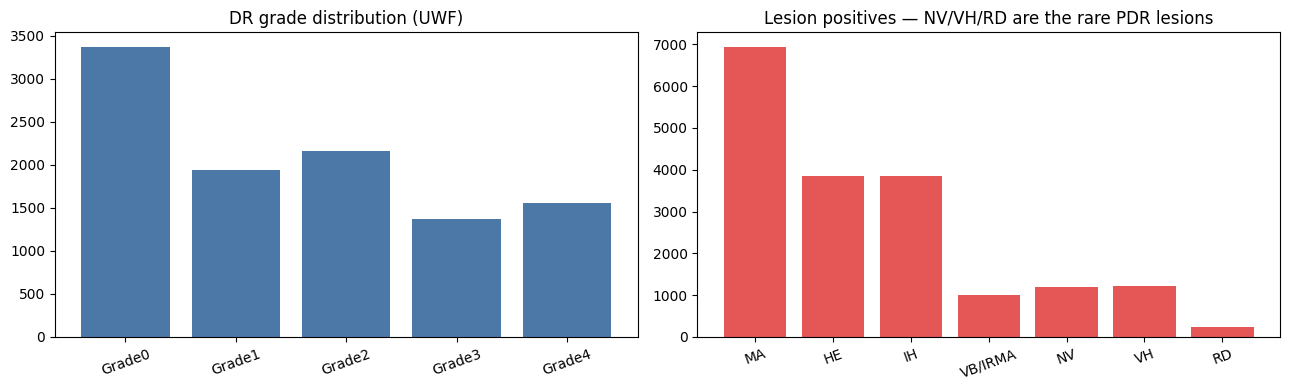

In [28]:
if DATA_AVAILABLE:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    g = df['grade'].value_counts().sort_index()
    ax[0].bar([f'Grade{i}' for i in g.index], g.values, color='#4C78A8')
    ax[0].set_title('DR grade distribution (UWF)'); ax[0].tick_params(axis='x', rotation=20)
    ax[1].bar(LESION_NAMES, [counts[n] for n in LESION_NAMES], color='#E45756')
    ax[1].set_title('Lesion positives — NV/VH/RD are the rare PDR lesions'); ax[1].tick_params(axis='x', rotation=20)
    plt.tight_layout(); plt.show()
else:
    print('[skip EDA] no data attached.')

## 16. Training — full ablation matrix (just run all cells)

On a GPU this loops the whole variant × seed matrix automatically. It is **safe to re-run**: every
`(variant, seed)` that already has a `results/metrics_*.json` is **skipped**, and any half-trained variant
**auto-resumes** from its last checkpoint (attach this experiment's checkpoint dataset so it persists across
Kaggle's 12-h limit). A wall-clock **`TIME_BUDGET_HRS`** guard stops launching new epochs before the
session is killed, so checkpoints are always safely backed up.

**Compute reality (dual-T4):** ResNet-50 @512px is ~10 min/epoch, so a full 60-epoch × 3-seed run spans
several sessions — exactly like the prior experiments, which is why resume exists. **`QUICK_PASS=True`
(default)** trains a reduced-epoch, single-seed pass so **one run-all yields a complete A/A′/B comparison
table**; set `QUICK_PASS=False` for the full publication-grade 60-epoch × 3-seed run across sessions.

In [29]:
import time as _time
import gc as _gc

QUICK_PASS      = True                                   # True: 1-session preliminary A/A'/B; False: full multi-seed
MATRIX_VARIANTS = ['shared', 'shared_mlp', 'separate']   # add 'adapter' for the middle-ground Model C
TIME_BUDGET_HRS = 11.0                                   # stop launching new epochs before Kaggle's 12h cutoff

if QUICK_PASS:
    MATRIX_SEEDS = [42]
    CFG['epochs'] = min(CFG['epochs'], 20)               # reduced budget so one session completes the matrix
else:
    MATRIX_SEEDS = CFG['seeds']                          # [42, 1, 2023] -> multi-session, resumable

_deadline = _time.time() + TIME_BUDGET_HRS * 3600
report = None

def _is_done(hm, sd):
    return os.path.exists(os.path.join(DIRS['results'], f'metrics_{hm}_s{sd}.json'))

if CFG['run_training'] and DATA_AVAILABLE:
    print(f"Matrix: variants={MATRIX_VARIANTS} x seeds={MATRIX_SEEDS} | epochs={CFG['epochs']} | "
          f"QUICK_PASS={QUICK_PASS}")
    _stopped = False
    for hm in MATRIX_VARIANTS:
        if _stopped:
            break
        for sd in MATRIX_SEEDS:
            if _is_done(hm, sd):
                print(f"[skip] {hm} seed {sd} already complete."); continue
            if _time.time() > _deadline:
                print("[budget] time budget reached; re-run the notebook to continue the matrix."); _stopped = True; break
            rcfg = dict(CFG); rcfg.update(head_mode=hm, seed=sd, ckpt_dir=DIRS['ckpt'], stop_time=_deadline)
            print(f"\n{'=' * 70}\nTRAIN  {hm}  seed {sd}\n{'=' * 70}")
            rep = train_variant(rcfg, train_df, val_df, test_df, IMG_DIR, DIRS)
            _gc.collect()                                # reap the finished variant's dataloader workers + model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            if rep is None:                              # hit the wall-clock budget mid-variant -> resume later
                _stopped = True; break
            report = rep
    if report is not None:
        print(f"\nLast completed: {report['head_mode']} seed {report['seed']} | "
              f"rare-recall {report['lesion']['mean_rare_recall']:.3f} | "
              f"macro-F1 {report['lesion']['macro_f1']:.3f}")
else:
    print("[skip] CFG['run_training'] is False or no dataset attached. The unit tests above already "
          "verified architecture, loss, gradient routing, and thresholds.")

Matrix: variants=['shared', 'shared_mlp', 'separate'] x seeds=[42] | epochs=20 | QUICK_PASS=True

TRAIN  shared  seed 42
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s] 


[shared_s42] head params 3,591 | total params 26,925,388 | split_sig da1ec8e21f22
[*] Resumed from /kaggle/input/checkpoint-heads-ablation/last_shared_s42.pth at epoch 18 (best_score 0.8059).



[shared_s42] Epoch 19/20  lr 1.0e-04  610s
   loss  train 3.1489  val 3.3450  (best_score 0.8059, patience 1/10)  [!] OVERFIT WARNING (train-val loss gap large)
   lesion macro-F1 0.753  PR-AUC 0.761  AUROC 0.943  bal-acc 0.859
   grade  kappa 0.899  acc 0.729
   RARE recall  NV 0.85  VH 0.93  RD 0.62   (mean 0.798, HEADLINE)



[shared_s42] Epoch 20/20  lr 5.0e-05  577s
   loss  train 3.0876  val 3.3315  (best_score 0.8059, patience 2/10)  [!] OVERFIT WARNING (train-val loss gap large)
   lesion macro-F1 0.763  PR-AUC 0.774  AUROC 0.946  bal-acc 0.855
   grade  kappa 0.903  acc 0.750
   RARE recall  NV 0.86  VH 0.88  RD 0.54   (mean 0.758, HEADLINE)
   [backup] OK -> krrishbaghla/checkpoint-heads-ablation | Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/krrishbaghla/checkpoint-heads-ablation


...


[separate_s42] Epoch 11/20  lr 1.0e-04  600s
   loss  train 3.2724  val 3.3506  (best_score 0.7941, patience 7/10)
   lesion macro-F1 0.737  PR-AUC 0.739  AUROC 0.942  bal-acc 0.856
   grade  kappa 0.901  acc 0.725
   RARE recall  NV 0.75  VH 0.89  RD 0.74   (mean 0.794, HEADLINE)



[separate_s42] Epoch 12/20  lr 1.0e-04  592s
   loss  train 3.2557  val 3.3239  (best_score 0.7941, patience 8/10)
   lesion macro-F1 0.740  PR-AUC 0.735  AUROC 0.943  bal-acc 0.870
   grade  kappa 0.894  acc 0.733
   RARE recall  NV 0.85  VH 0.89  RD 0.77   (mean 0.837, HEADLINE)
   [backup] OK -> krrishbaghla/checkpoint-heads-ablation | Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/krrishbaghla/checkpoint-heads-ablation



[separate_s42] Epoch 13/20  lr 1.0e-04  602s
   loss  train 3.2427  val 3.3333  (best_score 0.7941, patience 9/10)
   lesion macro-F1 0.736  PR-AUC 0.736  AUROC 0.943  bal-acc 0.865
   grade  kappa 0.903  acc 0.745
   RARE recall  NV 0.83  VH 0.94  RD 0.64   (mean 0.801, HEADLINE)



[separate_s42] Epoch 14/20  lr 1.0e-04  602s
   loss  train 3.2286  val 3.4104  (best_score 0.7941, patience 10/10)  [!] OVERFIT WARNING (train-val loss gap large)
   lesion macro-F1 0.745  PR-AUC 0.745  AUROC 0.944  bal-acc 0.872
   grade  kappa 0.894  acc 0.719
   RARE recall  NV 0.83  VH 0.90  RD 0.74   (mean 0.824, HEADLINE)
   [backup] OK -> krrishbaghla/checkpoint-heads-ablation | Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/krrishbaghla/checkpoint-heads-ablation
[separate_s42] Early stopping at epoch 14.
[*] Resumed from /kaggle/working/checkpoints/best_separate_s42.pth at epoch 4 (best_score 0.7941).


[separate_s42] TEST  macro-F1 0.689  mean-rare-recall 0.816  kappa 0.886  -> /kaggle/working/results/metrics_separate_s42.json
   [backup] OK -> krrishbaghla/checkpoint-heads-ablation | Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/krrishbaghla/checkpoint-heads-ablation

Last completed: separate seed 42 | rare-recall 0.816 | macro-F1 0.689


In [30]:
wertyu 

qwerty

NameError: name 'wertyuisdfghj' is not defined

## 17. Evaluation & plots
Aggregates every `results/metrics_*.json` produced so far (across variants and seeds) into the summary
table, the paired significance test, the capacity-vs-separation decomposition, and the comparison figure.
Renders whatever exists — after a single run it shows one row; after the full sweep it shows the paper table.

In [1]:
reports = load_reports(DIRS['results'])
if reports:
    rows = summary_table(reports)
    print("===== SUMMARY (mean over seeds) =====")
    for r in rows:
        print(f"{r['variant']:40s} rare-recall {r['mean_rare_recall_mean']:.3f}"
              f"±{r['mean_rare_recall_std']:.3f} | macro-F1 {r['macro_f1_mean']:.3f}"
              f"±{r['macro_f1_std']:.3f} | PR-AUC {r['macro_auprc_mean']:.3f}"
              f" | common-F1 {r['common_macro_f1_mean']:.3f} | head {r['head_params']:,}")
    write_summary_csv(reports, os.path.join(DIRS['results'], 'summary_table.csv'))
    if {'separate', 'shared_mlp'} <= set(reports):
        print("\n===== SIGNIFICANCE  (B separate  vs  A' shared_mlp) =====")
        for m in ['mean_rare_recall', 'macro_f1', 'common_macro_f1']:
            print(m, '->', paired_tests(reports, metric=m))
        print("\n===== CAPACITY vs SEPARATION =====")
        print(capacity_vs_separation(reports))
    plot_variant_comparison(rows, DIRS['plots'])          # cross-variant comparison figure
    print('Saved comparison figure to', DIRS['plots'])
else:
    print("No result JSONs yet. Train at least one variant (Section 16) to populate results/.")

# per-run figures for the variant just trained
if report is not None:
    tag = f"{CFG['head_mode']}_s{CFG['seed']}"
    plot_learning_curves(os.path.join(DIRS['logs'], f'train_{tag}.csv'), DIRS['plots'], tag)
    plot_confusion(report['grade']['confusion_matrix'], DIRS['plots'], tag)
    print('Saved per-run plots to', DIRS['plots'])

NameError: name 'load_reports' is not defined

## 18. Results

*(Populated after runs — the summary table above is the source. Fill this narrative once the full
matrix has trained.)*

Expected table shape (mean ± std over 3 seeds), headline column = **mean rare-recall**:

| Variant | Head params | Mean rare-recall ↑ | Macro-F1 ↑ | Macro PR-AUC ↑ | Common-F1 (guardrail) | Grade κ |
|---|---|---|---|---|---|---|
| A  (shared)     | 3,591  | … | … | … | … | … |
| A′ (shared_mlp) | 66,567 | … | … | … | … | … |
| B  (separate)   | 68,103 | … | … | … | … | … |
| C  (adapter)    | 74,631 | … | … | … | … | … |

Baselines to beat (folder-3 UWF): grade quadratic-κ 0.922, lesion macro-F1 0.738, macro-AUC 0.951.

## 19. Discussion

Read the result through the **capacity vs. separation decomposition**:

- **If B > A′ significantly (rare-recall ↑) with common-F1 flat →** separation, not parameters, drives the
  gain: the dedicated rare head escapes gradient domination by the common lesions (the BBN/Kang mechanism).
  Clinically meaningful — fewer missed PDR-defining lesions at matched precision. **Recommend the separate
  head.**
- **If B ≈ A′ but A′ > A →** the benefit is just added head capacity; a larger *shared* MLP does as well.
  A clean, publishable **negative result** that answers the reviewer and warns against over-engineering.
- **If B raises rare-recall but lowers common-F1 →** a genuine tradeoff (negative transfer resolved into a
  Pareto choice); report it and prefer **Model C (adapter)** if it recovers rare recall at lower common cost.

Also discuss: per-lesion threshold tuning vs. fixed-0.5 (a uniformly-applied, unclaimed improvement); the
worst rare false negatives (error analysis); and the residual confound that B gives rare lesions a deeper
path than common — which is *why* A′ (a 2-layer shared head) is the honest control, not A.

## 20. Conclusion

A capacity-controlled ablation of head topology for rare PDR-lesion detection on MMRDR-UWF. By comparing a
dedicated rare head (**B**) against a **capacity-matched shared MLP head (A′)** — not merely the minimal
linear baseline — the study attributes any rare-recall change to *head separation* rather than parameter
count, directly answering the strongest reviewer question. All proven pipeline techniques (asymmetric focal
loss, SupCon, AMP, grad-clip, ReduceLROnPlateau, stratified split, Kaggle-resumable checkpointing) are
reused unchanged so the head is the sole independent variable, and two uniformly-applied upgrades
(per-lesion thresholds, clinical-metric selection) improve every variant equally.

## 21. References

1. Q. Tang *et al.*, "A multimodal retinal image dataset for diabetic retinopathy detection using foundation models," *Scientific Data*, 2026. doi:10.1038/s41597-026-07005-9.
2. A. Foo, W. Hsu, M. L. Lee, G. Lim, T. Y. Wong, "Multi-task learning for diabetic retinopathy grading and lesion segmentation," *AAAI*, 34(8):13267–13272, 2020. doi:10.1609/aaai.v34i08.7035.
3. Y. Zhou *et al.*, "Collaborative learning of semi-supervised segmentation and classification for medical images," *CVPR*, 2019.
4. "Multi-task deep learning framework combining CNN, vision transformers and PSO for diabetic retinopathy diagnosis and lesion localization," *Scientific Reports*, 2025. doi:10.1038/s41598-025-18742-z.
5. I. Misra, A. Shrivastava, A. Gupta, M. Hebert, "Cross-stitch networks for multi-task learning," *CVPR*, 3994–4003, 2016.
6. T. Standley *et al.*, "Which tasks should be learned together in multi-task learning?," *ICML*, 2020 (arXiv:1905.07553); C. Fifty *et al.*, "Efficiently identifying task groupings for multi-task learning," *NeurIPS*, 2021 (arXiv:2109.04617).
7. S. Vandenhende *et al.*, "Multi-task learning for dense prediction tasks: a survey," *IEEE TPAMI*, 2021 (arXiv:2004.13379).
8. T.-Y. Lin, P. Goyal, R. Girshick, K. He, P. Dollár, "Focal loss for dense object detection," *ICCV*, 2980–2988, 2017.
9. E. Ben-Baruch *et al.*, "Asymmetric loss for multi-label classification," *ICCV*, 82–91, 2021.
10. Y. Cui, M. Jia, T.-Y. Lin, Y. Song, S. Belongie, "Class-balanced loss based on effective number of samples," *CVPR*, 9268–9277, 2019.
11. K. Cao, C. Wei, A. Gaidon, N. Arechiga, T. Ma, "Learning imbalanced datasets with label-distribution-aware margin loss," *NeurIPS*, 2019 (arXiv:1906.07413).
12. B. Kang *et al.*, "Decoupling representation and classifier for long-tailed recognition," *ICLR*, 2020 (arXiv:1910.09217).
13. B. Zhou, Q. Cui, X.-S. Wei, Z.-M. Chen, "BBN: bilateral-branch network with cumulative learning for long-tailed visual recognition," *CVPR*, 9716–9725, 2020.
14. G. Holste *et al.*, "Towards long-tailed, multi-label disease classification from chest X-ray: overview of the CXR-LT challenge," *Medical Image Analysis*, 2024. doi:10.1016/j.media.2024.103224.
15. N. Shazeer *et al.*, "Outrageously large neural networks: the sparsely-gated mixture-of-experts layer," *ICLR*, 2017 (arXiv:1701.06538).
16. N. Houlsby *et al.*, "Parameter-efficient transfer learning for NLP," *ICML*, PMLR 97:2790–2799, 2019.
17. "A multi-label detection deep learning model with attention-guided image enhancement for retinal images," *Micromachines*, 14(3):705, 2023.
18. P. Khosla *et al.*, "Supervised contrastive learning," *NeurIPS*, 2020 (arXiv:2004.11362).
19. Y. Zhou, M. A. Chia, S. K. Wagner *et al.*, "A foundation model for generalizable disease detection from retinal images," *Nature*, 622(7981):156–163, 2023. doi:10.1038/s41586-023-06555-x.